In [ ]:
!pip install breizhcrops

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Configuration
DATA_PATH = '/content/drive/MyDrive/COMP0173_Applying_New_Context/data'
BATCH_SIZE = 64
EPOCHS = 50
NUM_CLASSES = 9

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Load the unscaled MTVI2 datasets
X_train = np.load(os.path.join(DATA_PATH, 'X_train_final_MTVI2_unscaled.npy'))
y_train = np.load(os.path.join(DATA_PATH, 'y_train_final_MTVI2_unscaled.npy'))
X_val = np.load(os.path.join(DATA_PATH, 'X_val_final_MTVI2_unscaled.npy'))
y_val = np.load(os.path.join(DATA_PATH, 'y_val_final_MTVI2_unscaled.npy'))

input_shape = (X_train.shape[1], X_train.shape[2])

Mounted at /content/drive


#Testing InceptionTime

In [ ]:
# InceptionTime Architecture
def inception_module(input_tensor, filters, kernel_sizes=[10, 20, 40], bottleneck_size=32):
    bottleneck = layers.Conv1D(filters=bottleneck_size, kernel_size=1, padding='same', activation='relu', use_bias=False)(input_tensor)

    conv_list = []
    for kernel_size in kernel_sizes:
        conv = layers.Conv1D(filters=filters, kernel_size=kernel_size, padding='same', activation='relu', use_bias=False)(bottleneck)
        conv_list.append(conv)

    max_pool = layers.MaxPooling1D(pool_size=3, strides=1, padding='same')(input_tensor)
    conv_maxpool = layers.Conv1D(filters=filters, kernel_size=1, padding='same', activation='relu', use_bias=False)(max_pool)
    conv_list.append(conv_maxpool)

    x = layers.Concatenate(axis=-1)(conv_list)
    x = layers.BatchNormalization()(x)
    return layers.Activation('relu')(x)

def build_inception_time(input_shape, num_classes, depth=6, filters=32):
    input_layer = layers.Input(shape=input_shape)
    x = input_layer
    res = input_layer

    for d in range(depth):
        x = inception_module(x, filters)

        if d % 3 == 2:
            res = layers.Conv1D(filters=x.shape[-1], kernel_size=1, padding='same', use_bias=False)(res)
            res = layers.BatchNormalization()(res)
            x = layers.Add()([x, res])
            x = layers.Activation('relu')(x)
            res = x

    x = layers.GlobalAveragePooling1D()(x)
    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=input_layer, outputs=output_layer)

# Using the input shape from your verification (48, 12)
model = build_inception_time((48, 12), 9)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='macro_f1')]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 48, 32)    │        384 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 48, 12)    │          0 │ input_layer[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 48, 32)    │     10,240 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 48, 32)    │     20,480 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 48, 32)    │     40,960 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 48, 32)    │        384 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48, 128)   │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 128)   │        512 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 48, 32)    │      4,096 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 48, 128)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 48, 32)    │     10,240 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 48, 32)    │     20,480 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 48, 32)    │     40,960 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 48, 32)    │      4,096 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 48, 128)   │          0 │ conv1d_6[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_7[0][0],   │
│                     │                   │            │ conv1d_8[0][0],   │
│                     │                   │            │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 128)   │        512 │ concatenate_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 128)   │          0 │ batch_normalizat

 Total params: 494,985 (1.89 MB)

 Trainable params: 492,937 (1.88 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_macro_f1', patience=10, mode='max', restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', factor=0.5, patience=5, mode='max')
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.6548 - loss: 0.8841 - macro_f1: 0.5234 - val_accuracy: 0.6005 - val_loss: 0.9820 - val_macro_f1: 0.4626 - learning_rate: 0.0010
Epoch 2/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7624 - loss: 0.6081 - macro_f1: 0.7135 - val_accuracy: 0.6925 - val_loss: 0.7521 - val_macro_f1: 0.4891 - learning_rate: 0.0010
Epoch 3/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7833 - loss: 0.5419 - macro_f1: 0.7817 - val_accuracy: 0.6873 - val_loss: 0.7112 - val_macro_f1: 0.5296 - learning_rate: 0.0010
Epoch 4/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8052 - loss: 0.4861 - macro_f1: 0.8283 - val_accuracy: 0.6785 - val_loss: 0.7344 - val_macro_f1: 0.5137 - learning_rate: 0.0010
Epoch 5/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8140 - loss: 0.4539 - macro_f1: 0.8405 - val_accuracy: 0.6787 - val_loss: 0.8164 - val_macro_f1: 0.5076 - learning_rate: 0.0010
Epoch 6/50
348/348 ━━━━━

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
X_test shape: (6000, 48, 12), y_test shape: (6000, 9)

Per-Class Metrics
 Class ID        Class Name  Support  Precision  Recall  F1-Score
        0            Barley      257     0.4844  0.9066    0.6314
        1             Wheat      978     0.9160  0.8139    0.8619
        2          Rapeseed      128     0.6510  0.9766    0.7812
        3              Corn     1510     0.9698  0.9146    0.9414
        4         Sunflower       10     1.0000  0.2000    0.3333
        5          Orchards       44     0.0846  0.5227    0.1456
        6              Nuts       10     0.0000  0.0000    0.0000
        7 Permanent Meadows     1169     0.4626  0.5920    0.5193
        8 Temporary Meadows     1894     0.6904  0.4604    0.5524

Overall Metrics
Overall Accuracy (OA):        0.6873
Average Accuracy (Balanced):  0.5985
Macro Precision:              0.5843
Macro Recall (WCA):           0.5985
Macro F1-Score:               0.5296
Macro Jaccard Index (IoU

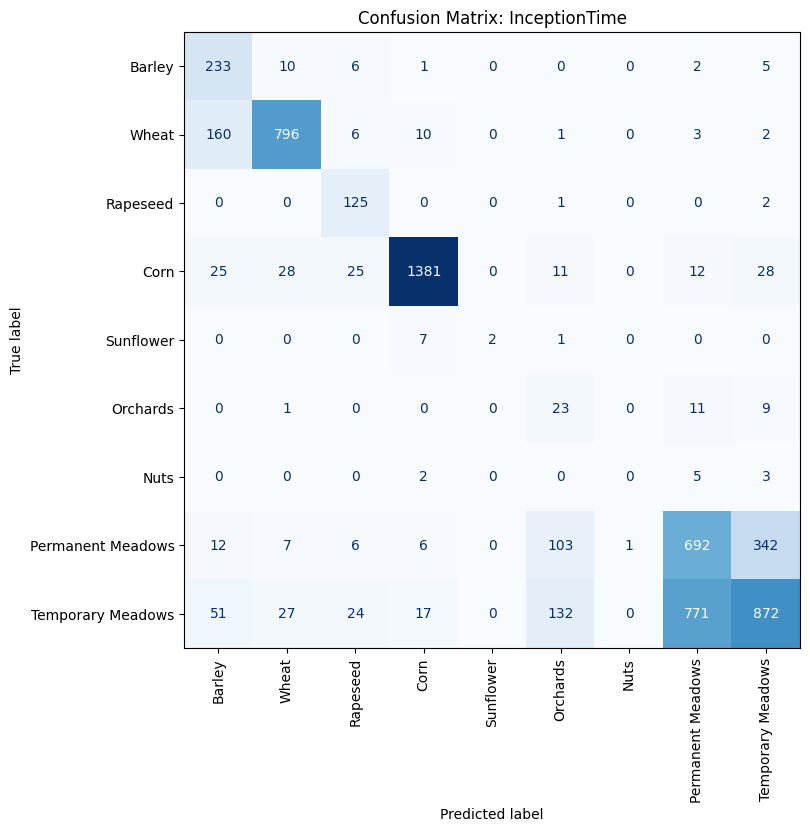

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, jaccard_score, ConfusionMatrixDisplay, balanced_accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

y_pred_proba = model.predict(X_val)
y_pred = np.argmax(y_pred_proba, axis=-1)
y_true = np.argmax(y_val, axis=-1)

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(NUM_CLASSES), zero_division=0
)

oa = np.mean(y_pred == y_true)
avg_accuracy = balanced_accuracy_score(y_true, y_pred) # Mean of per-class recalls
macro_iou = jaccard_score(y_true, y_pred, average='macro', zero_division=0)

results_df = pd.DataFrame({
    'Class ID': range(NUM_CLASSES),
    'Class Name': class_names,
    'Support': support,
    'Precision': np.round(precision, 4),
    'Recall': np.round(recall, 4),
    'F1-Score': np.round(f1, 4)
})

print(f"X_test shape: {X_val.shape}, y_test shape: {y_val.shape}")
print("\nPer-Class Metrics")
print(results_df.to_string(index=False))

print("\nOverall Metrics")
print(f"Overall Accuracy (OA):        {oa:.4f}")
print(f"Average Accuracy (Balanced):  {avg_accuracy:.4f}")
print(f"Macro Precision:              {np.mean(precision):.4f}")
print(f"Macro Recall (WCA):           {np.mean(recall):.4f}")
print(f"Macro F1-Score:               {np.mean(f1):.4f}")
print(f"Macro Jaccard Index (IoU):    {macro_iou:.4f}")

# 5. Confusion Matrix Plot
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=class_names, xticks_rotation='vertical', cmap='Blues', ax=ax, colorbar=False
)
plt.title("Confusion Matrix: InceptionTime")
plt.show()

#Testing Transformers

In [ ]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

def build_transformer(input_shape, num_classes, num_blocks=4, head_size=128, num_heads=4, ff_dim=128, dropout=0.1):
    inputs = layers.Input(shape=input_shape)

    seq_len = input_shape[0]
    embed_dim = input_shape[1]

    pos_indices = layers.Lambda(lambda x: tf.expand_dims(tf.range(seq_len), 0))(inputs)
    pos_embeddings = layers.Embedding(input_dim=seq_len, output_dim=embed_dim)(pos_indices)

    x = layers.Add()([inputs, pos_embeddings])

    for _ in range(num_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)

transformer_model = build_transformer((48, 12), 9)
transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.F1Score(average="macro", name="macro_f1")]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_macro_f1', patience=12, mode='max', restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', factor=0.5, patience=6, mode='max')
]

history = transformer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.3793 - loss: 1.5844 - macro_f1: 0.2707 - val_accuracy: 0.4400 - val_loss: 1.4253 - val_macro_f1: 0.2471 - learning_rate: 1.0000e-04
Epoch 2/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5218 - loss: 1.1780 - macro_f1: 0.3884 - val_accuracy: 0.5435 - val_loss: 1.1718 - val_macro_f1: 0.3561 - learning_rate: 1.0000e-04
Epoch 3/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5612 - loss: 1.0568 - macro_f1: 0.4231 - val_accuracy: 0.5705 - val_loss: 1.0578 - val_macro_f1: 0.4009 - learning_rate: 1.0000e-04
Epoch 4/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5902 - loss: 0.9786 - macro_f1: 0.4493 - val_accuracy: 0.5898 - val_loss: 1.0291 - val_macro_f1: 0.4227 - learning_rate: 1.0000e-04
Epoch 5/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6110 - loss: 0.9373 - macro_f1: 0.4695 - val_accuracy: 0.5785 - val_loss: 1.0374 - val_macro_f1: 0.4069 - learning_rate: 1.0000e-04
Epoc

188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step
X_test shape: (6000, 48, 12), y_test shape: (6000, 9)

Per-Class Metrics
 Class ID        Class Name  Support  Precision  Recall  F1-Score
        0            Barley      257     0.6110  0.9105    0.7312
        1             Wheat      978     0.9163  0.9294    0.9228
        2          Rapeseed      128     0.8552  0.9688    0.9084
        3              Corn     1510     0.9649  0.9278    0.9460
        4         Sunflower       10     0.4000  0.2000    0.2667
        5          Orchards       44     0.0657  0.6364    0.1191
        6              Nuts       10     0.0000  0.0000    0.0000
        7 Permanent Meadows     1169     0.4900  0.5894    0.5351
        8 Temporary Meadows     1894     0.7244  0.4551    0.5590

Overall Metrics
Overall Accuracy (OA):        0.7082
Average Accuracy (Balanced):  0.6242
Macro Precision:              0.5586
Macro Recall (WCA):           0.6242
Macro F1-Score:               0.5543
Macro Jaccard Index (I

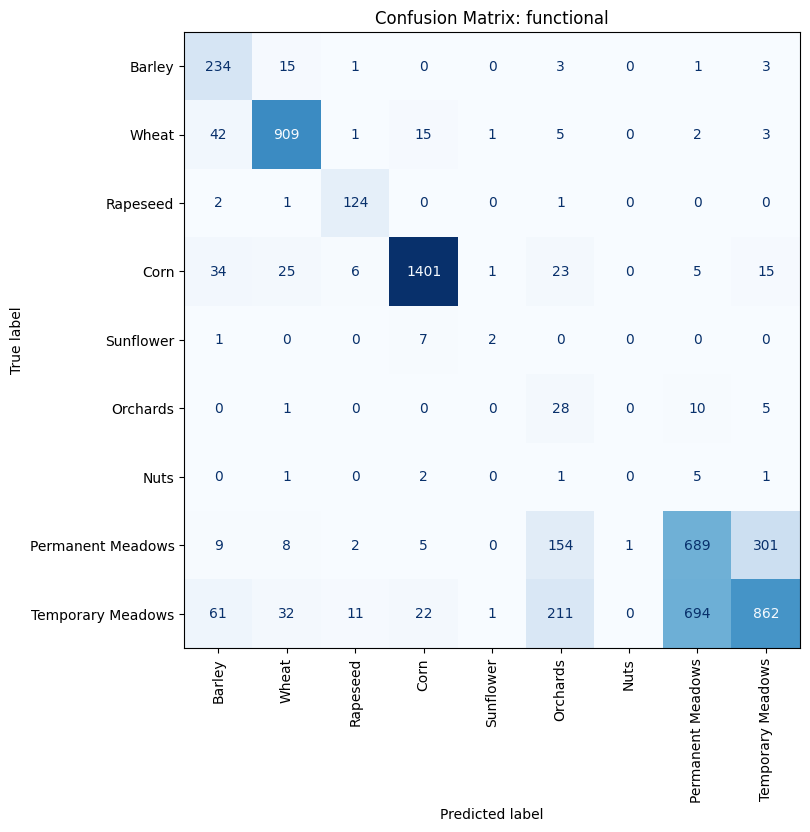

In [ ]:
y_pred_proba = transformer_model.predict(X_val)
y_pred = np.argmax(y_pred_proba, axis=-1)
y_true = np.argmax(y_val, axis=-1)

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(NUM_CLASSES), zero_division=0
)

oa = np.mean(y_pred == y_true)
avg_accuracy = balanced_accuracy_score(y_true, y_pred)
macro_iou = jaccard_score(y_true, y_pred, average='macro', zero_division=0)

results_df = pd.DataFrame({
    'Class ID': range(NUM_CLASSES),
    'Class Name': class_names,
    'Support': support,
    'Precision': np.round(precision, 4),
    'Recall': np.round(recall, 4),
    'F1-Score': np.round(f1, 4)
})

print(f"X_test shape: {X_val.shape}, y_test shape: {y_val.shape}")
print("\nPer-Class Metrics")
print(results_df.to_string(index=False))

print("\nOverall Metrics")
print(f"Overall Accuracy (OA):        {oa:.4f}")
print(f"Average Accuracy (Balanced):  {avg_accuracy:.4f}")
print(f"Macro Precision:              {np.mean(precision):.4f}")
print(f"Macro Recall (WCA):           {np.mean(recall):.4f}")
print(f"Macro F1-Score:               {np.mean(f1):.4f}")
print(f"Macro Jaccard Index (IoU):    {macro_iou:.4f}")

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=class_names,
    xticks_rotation='vertical',
    cmap='Blues',
    ax=ax,
    colorbar=False
)
plt.title(f"Confusion Matrix: {model.name}")
plt.show()

#LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_lstm(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Layer Normalization to handle spectral variations
    x = layers.LayerNormalization()(inputs)

    # Stacked Bidirectional LSTM
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Bidirectional(layers.LSTM(64))(x)

    # Dense classification head
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="LSTM_Model")

lstm_model = build_lstm((48, 12), 9)

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.F1Score(average="macro", name="macro_f1")
    ]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1',
        patience=12,
        mode='max',
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_macro_f1',
        factor=0.5,
        patience=6,
        mode='max'
    )
]

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6233 - loss: 0.9500 - macro_f1: 0.4819 - val_accuracy: 0.6573 - val_loss: 0.8260 - val_macro_f1: 0.4595 - learning_rate: 0.0010
Epoch 2/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7239 - loss: 0.6812 - macro_f1: 0.6431 - val_accuracy: 0.6558 - val_loss: 0.7968 - val_macro_f1: 0.4766 - learning_rate: 0.0010
Epoch 3/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.7452 - loss: 0.6245 - macro_f1: 0.6916 - val_accuracy: 0.6795 - val_loss: 0.7495 - val_macro_f1: 0.5058 - learning_rate: 0.0010
Epoch 4/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7649 - loss: 0.5823 - macro_f1: 0.7247 - val_accuracy: 0.6620 - val_loss: 0.7901 - val_macro_f1: 0.5019 - learning_rate: 0.0010
Epoch 5/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7754 - loss: 0.5537 - macro_f1: 0.7586 - val_accuracy: 0.6965 - val_loss: 0.6923 - val_macro_f1: 0.5316 - learning_rate: 0.0010
Epoch 6/50
348/348 ━━━━

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
X_test shape: (6000, 48, 12)

Per-Class Metrics
 Class ID        Class Name  Support  Precision  Recall  F1-Score
        0            Barley      257     0.6474  0.9144    0.7581
        1             Wheat      978     0.9543  0.8967    0.9246
        2          Rapeseed      128     0.7427  0.9922    0.8495
        3              Corn     1510     0.9498  0.9649    0.9573
        4         Sunflower       10     1.0000  0.2000    0.3333
        5          Orchards       44     0.0610  0.6364    0.1113
        6              Nuts       10     0.0000  0.0000    0.0000
        7 Permanent Meadows     1169     0.5191  0.5586    0.5381
        8 Temporary Meadows     1894     0.7246  0.4931    0.5869

Overall Metrics
Overall Accuracy (OA):        0.7188
Average Accuracy (Balanced):  0.6285
Macro F1-Score:               0.5621
Macro Jaccard Index (IoU):    0.4632


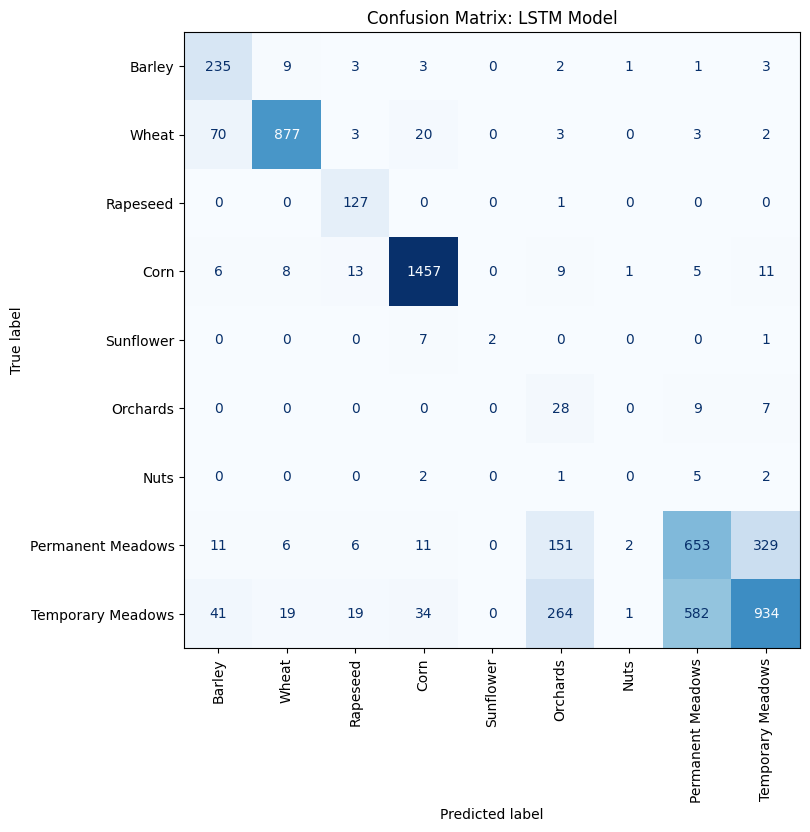

In [ ]:
# Generate predictions
y_pred_proba = lstm_model.predict(X_val)
y_pred = np.argmax(y_pred_proba, axis=-1)
y_true = np.argmax(y_val, axis=-1)

# Calculate metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(9), zero_division=0
)
oa = np.mean(y_pred == y_true)
avg_accuracy = balanced_accuracy_score(y_true, y_pred)
macro_iou = jaccard_score(y_true, y_pred, average='macro', zero_division=0)

# Reporting
results_df = pd.DataFrame({
    'Class ID': range(9),
    'Class Name': class_names,
    'Support': support,
    'Precision': np.round(precision, 4),
    'Recall': np.round(recall, 4),
    'F1-Score': np.round(f1, 4)
})

print(f"X_test shape: {X_val.shape}")
print("\nPer-Class Metrics")
print(results_df.to_string(index=False))

print("\nOverall Metrics")
print(f"Overall Accuracy (OA):        {oa:.4f}")
print(f"Average Accuracy (Balanced):  {avg_accuracy:.4f}")
print(f"Macro F1-Score:               {np.mean(f1):.4f}")
print(f"Macro Jaccard Index (IoU):    {macro_iou:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=class_names,
    xticks_rotation='vertical',
    cmap='Blues',
    ax=ax,
    colorbar=False
)
plt.title("Confusion Matrix: LSTM Model")
plt.show()